# 02 — Capacidade de Consumo e Dinamismo Econômico

**Objetivo**: analisar renda, PIB, volume Pix e dinamismo financeiro dos municípios.

**Inputs**: `data/processed/trusted_municipios_eda.parquet`, `raw_bcb_pix_transacoes`.

**Outputs**: figuras e tabela de estatísticas por estrato populacional.

In [2]:
# Imports
import logging

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import PROCESSED_DATA_DIR
from src.utils.bigquery import read_table_to_dataframe
from src.utils.eda import plot_boxplot_by_group, plot_distribution, save_figure, save_json

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

In [3]:
# Leitura
df = pd.read_parquet(PROCESSED_DATA_DIR / "trusted_municipios_eda.parquet")
df_raw_pix = read_table_to_dataframe("raw_bcb_pix_transacoes")
logger.info("trusted: %s, raw_pix: %s", df.shape, df_raw_pix.shape)

2026-08-26 12:48:54,196 - INFO - trusted: (5570, 32), raw_pix: (183789, 21)


## 1. Distribuição de renda e PIB

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
2026-08-26 12:48:55,137 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/figures/02_dist_log_rendimento_domiciliar_per_capita.png


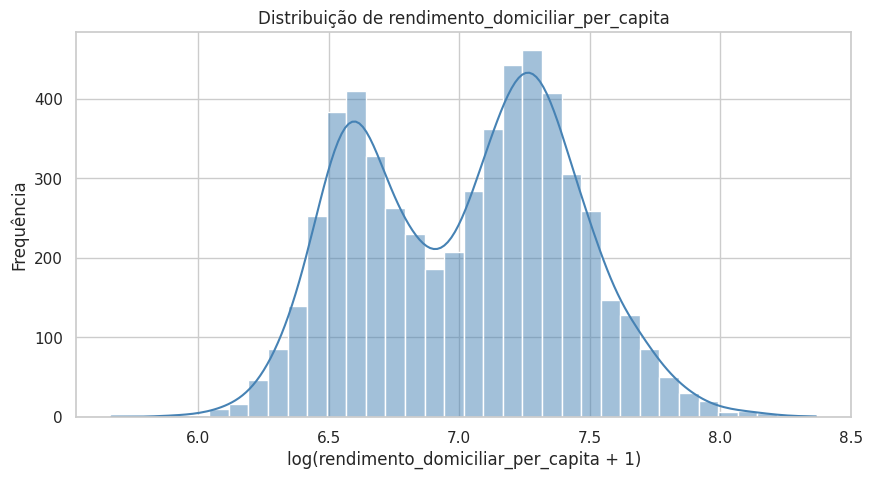

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
2026-08-26 12:48:56,017 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/figures/02_dist_log_pib_per_capita.png


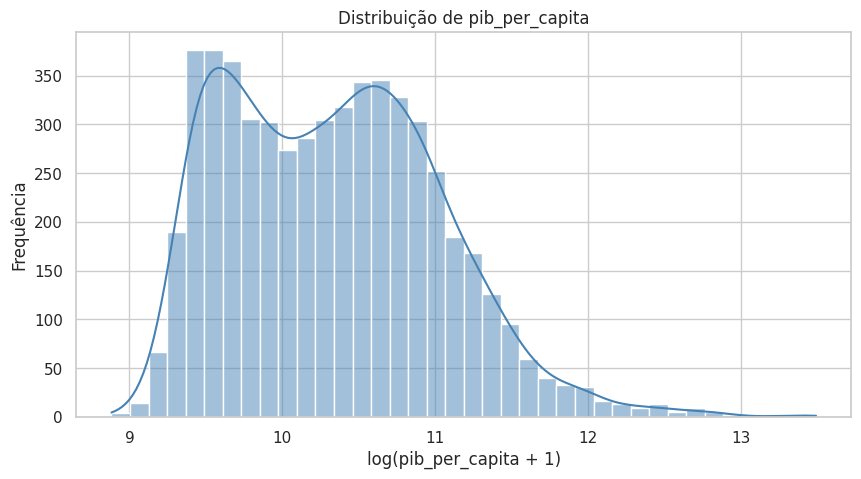

In [4]:
for col in ["rendimento_domiciliar_per_capita", "pib_per_capita"]:
    plot_distribution(df, col, log_scale=True, filename=f"02_dist_log_{col}.png")
    plt.show()

## 2. Pix vs PIB per capita

2026-08-26 12:48:58,153 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/figures/02_pix_vs_pib.png


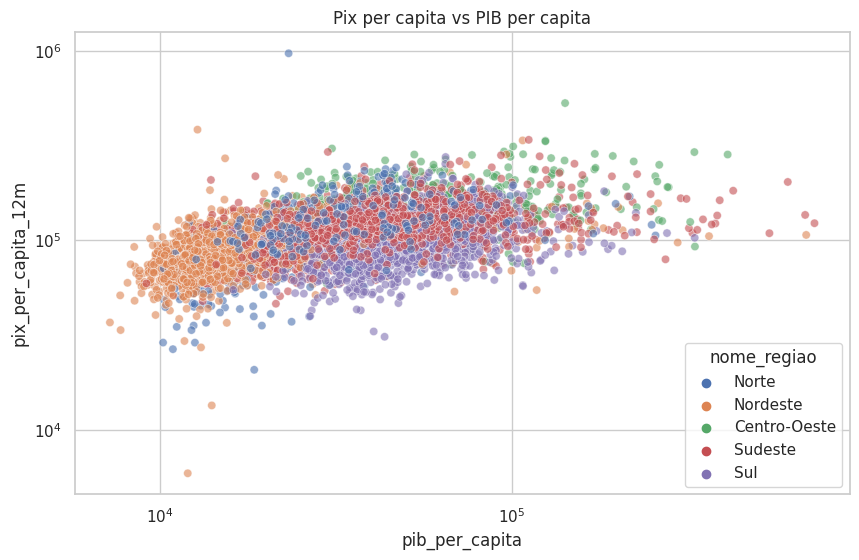

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df, x="pib_per_capita", y="pix_per_capita_12m", hue="nome_regiao", alpha=0.6, ax=ax
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Pix per capita vs PIB per capita")
save_figure(fig, "02_pix_vs_pib.png")
plt.show()

## 3. Sazonalidade e evolução do Pix

2026-08-26 12:49:00,354 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/figures/02_serie_pix.png


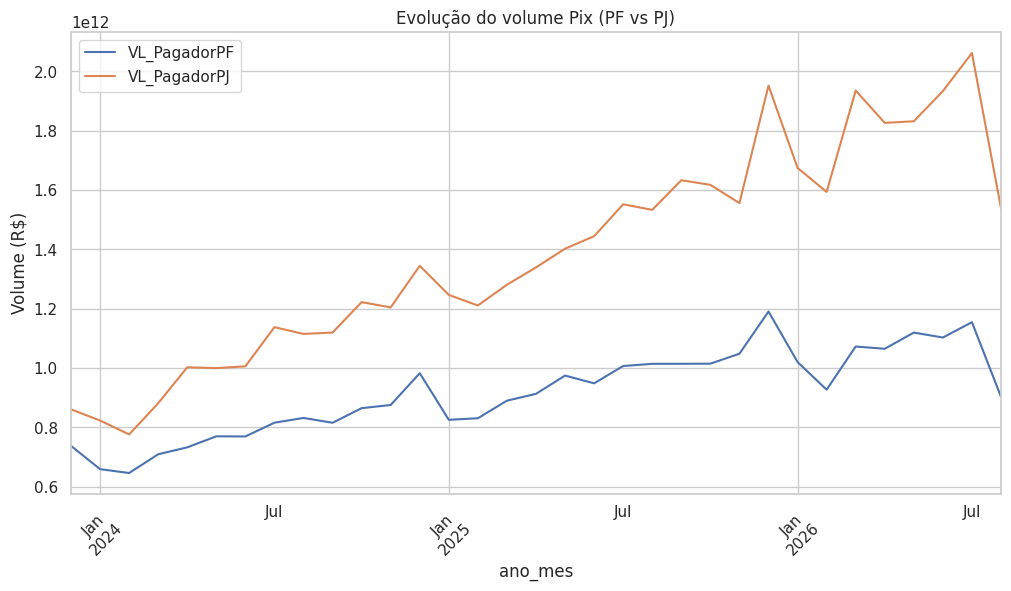

In [6]:
df_raw_pix["ano_mes"] = pd.to_datetime(
    df_raw_pix["AnoMes"].astype(str), format="%Y%m"
)

serie = (
    df_raw_pix.groupby("ano_mes")
    .agg(
        VL_PagadorPF=("VL_PagadorPF", "sum"),
        VL_PagadorPJ=("VL_PagadorPJ", "sum"),
    )
    .reset_index()
    .sort_values("ano_mes")
)

fig, ax = plt.subplots(figsize=(12, 6))
serie.plot(x="ano_mes", y=["VL_PagadorPF", "VL_PagadorPJ"], ax=ax)
ax.set_title("Evolução do volume Pix (PF vs PJ)")
ax.set_ylabel("Volume (R$)")
ax.tick_params(axis="x", rotation=45)
save_figure(fig, "02_serie_pix.png")
plt.show()

## 4. Estatísticas por estrato populacional

In [7]:
stats = (
    df.groupby("estrato_populacional")
    .agg(
        rendimento_domiciliar_per_capita=("rendimento_domiciliar_per_capita", "median"),
        pib_per_capita=("pib_per_capita", "median"),
        pix_per_capita_12m=("pix_per_capita_12m", "median"),
    )
    .round(2)
)
display(stats)

/tmp/ipykernel_645030/4291856.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("estrato_populacional")


,rendimento_domiciliar_per_capita,pib_per_capita,pix_per_capita_12m
estrato_populacional,,,
pequena,1145.36,28216.86,96532.71
media,1460.71,42068.32,134321.13
grande,2079.68,56227.29,182175.47


## 5. Boxplots por estrato

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
2026-08-26 12:49:01,592 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/figures/02_boxplot_rendimento_domiciliar_per_capita_estrato.png


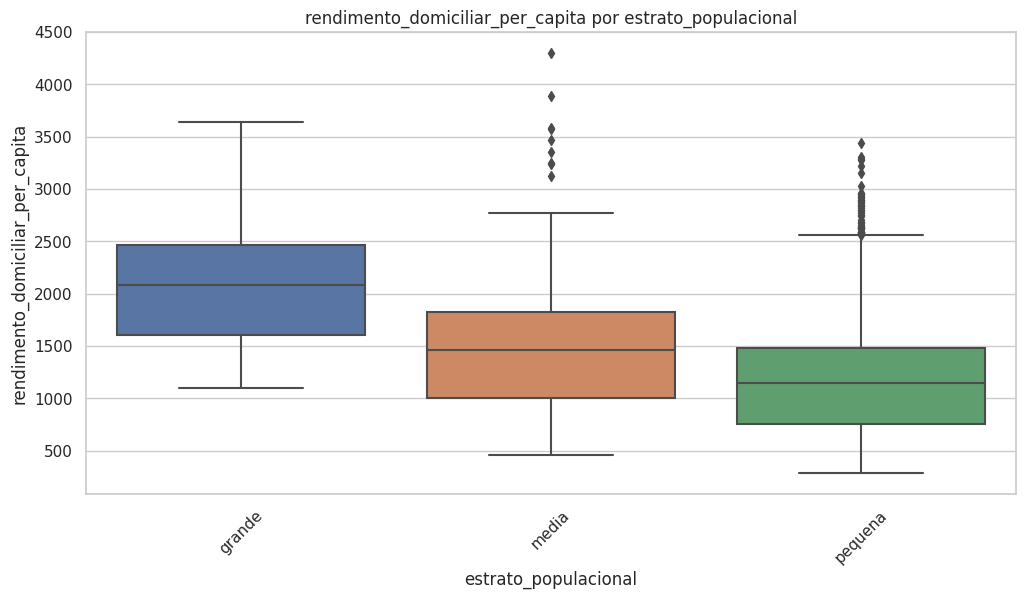

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
2026-08-26 12:49:02,506 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/figures/02_boxplot_pib_per_capita_estrato.png


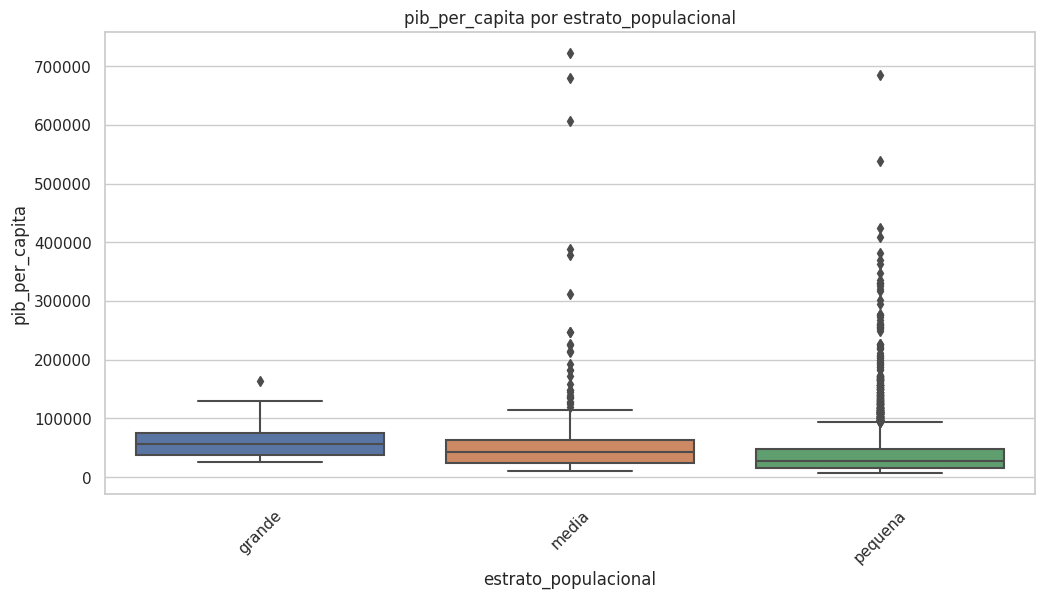

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
2026-08-26 12:49:03,456 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/figures/02_boxplot_pix_per_capita_12m_estrato.png


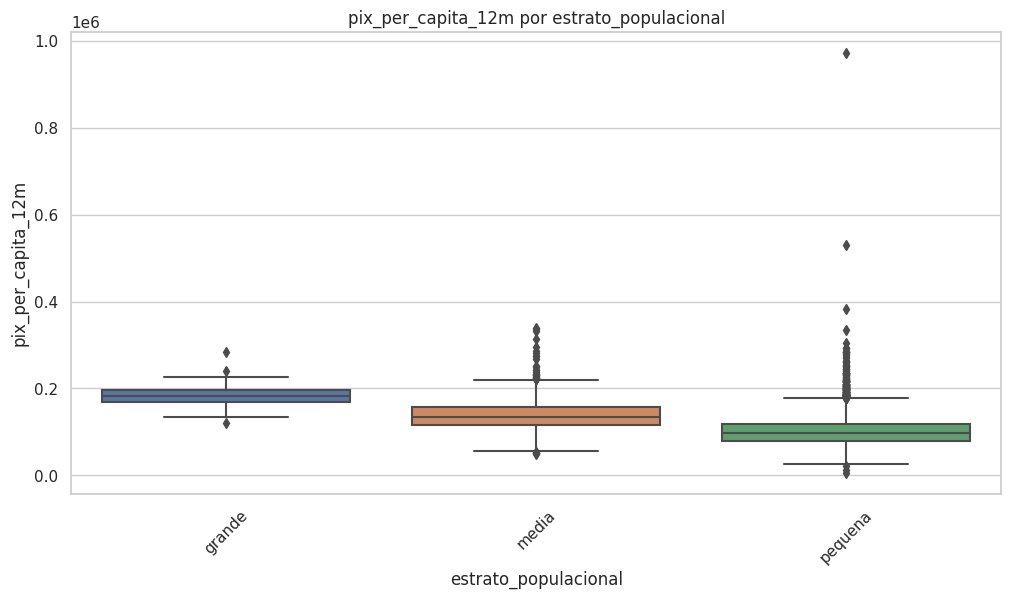

In [8]:
for col in ["rendimento_domiciliar_per_capita", "pib_per_capita", "pix_per_capita_12m"]:
    plot_boxplot_by_group(
        df, col, "estrato_populacional", filename=f"02_boxplot_{col}_estrato.png"
    )
    plt.show()

## 6. Municípios com alta adoção Pix e baixa renda

In [9]:
mediana_pix = df["pix_per_capita_12m"].median()
mediana_renda = df["rendimento_domiciliar_per_capita"].median()

df_oportunidade = df[
    (df["pix_per_capita_12m"] > mediana_pix)
    & (df["rendimento_domiciliar_per_capita"] < mediana_renda)
]

logger.info("Municípios com alto Pix e baixa renda: %d", len(df_oportunidade))
display(
    df_oportunidade[["nome_municipio", "sigla_uf", "pix_per_capita_12m", "rendimento_domiciliar_per_capita"]]
    .sort_values("pix_per_capita_12m", ascending=False)
    .head(10)
)

2026-08-26 12:49:03,810 - INFO - Municípios com alto Pix e baixa renda: 869


,nome_municipio,sigla_uf,pix_per_capita_12m,rendimento_domiciliar_per_capita
3912,Pacaraima,RR,971711.889933,578.04
2639,Jericó,PB,383923.866009,811.24
2661,Mato Grosso,PB,270902.268305,812.10
1128,Balsas,MA,250890.738800,1166.62
5554,Miranorte,TO,233200.263153,1172.19
1001,Trombas,GO,230473.110240,1118.10
2968,Santa Cruz do Capibaribe,PE,221263.271574,965.72
2537,Tucumã,PA,220788.636860,1120.97
941,Iaciara,GO,218522.182392,919.34
3888,Nova Mamoré,RO,216412.238911,1152.19


In [10]:
report = {
    "estatisticas_por_estrato": stats.to_dict(),
    "municipios_alto_pix_baixa_renda": int(len(df_oportunidade)),
}
save_json(report, "02_economia_dinamismo.json")

2026-08-26 12:49:03,947 - INFO - JSON salvo em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/reports/02_economia_dinamismo.json


PosixPath('/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/reports/02_economia_dinamismo.json')

## Resumo Executivo

Este notebook gerou o relatório `02_economia_dinamismo.json`. Abaixo segue um resumo legível dos principais resultados.

In [ ]:
# Resumo legível do relatório gerado
import json
from pathlib import Path

report_path = Path("data/processed/reports/02_economia_dinamismo.json")
if report_path.exists():
    with open(report_path, "r", encoding="utf-8") as f:
        report = json.load(f)
    print(json.dumps(report, indent=2, ensure_ascii=False))
else:
    print("Relatório ainda não foi gerado.")